
# Bai thuc hanh so 8 - Phan 1: MÔ HÌNH ANN (MULTI LAYER PERCEPTRON CLASSIFIER VÀ ỨNG DỤNG PCA)
- Trong phần thực hành này, chúng ta sẽ bắt đầu với việc xây dựng mô hình ANN bằng các bước như lý thuyết,
chỉ với các công cụ cơ bản (numpy) và thực hiện trên tập dữ liệu nhân tạo. Sau đó chúng ta sẽ dùng PCA để
giảm số chiều của một vài tập dữ liệu thực tế và áp dụng mô hình ANN của chúng ta để phân lớp.


## Vi du 1: 
- Ý tưởng ví dụ này tham khảo từ https://cs231n.github.io/neural-networks-case-study/ , với dữ liệu
nhân tạo để minh họa (toy example).
- Trước hết chúng ta tạo một tập dữ liệu được chia vào 03 phân lớp khác nhau trong không gian d =2 chiều
(để có thể hiển thị ra mặt phẳng). Các phân lớp sẽ được tạo sao cho không có hai phân lớp nào là tách được
tuyến tính (linearly separable). Đoạn lệnh dưới đây để tạo dữ liệu theo ý tưởng như vậ

In [8]:
# import the necessary libraries
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as plt 

In [9]:
N = 200 # number of points per class
d = 2 # dimensionality
C = 3 # number of classes
X = np.zeros((d, N*C)) # data matrix (each row = single example)
y = np.zeros(N*C, dtype='uint8') # class labels

for j in range(C):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    # goc quay cua cac diem 
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 #  
    # chuyen doi tu he tao do cuc sang he toa do decat 
    X[:,ix] = np.c_[r*np.sin(t), r*np.cos(t)].T
    y[ix] = j

- Trong đoạn lệnh trên, ta đã tạo dữ liệu (là các điểm – 2 chiều) bằng cách tạo các điểm theo tọa độ cực: từ
một tâm điểm, ta vừa tăng dần bán kính r, đồng thời tăng dần góc t theo chỉ số của điểm, dẫn đến các điểm
sẽ được phân bố xa dần tâm và tạo thành vệt xoáy. Ngoài ra ta bổ sung yếu tố ngẫu nhiên
np.random.randn(N)*0.2 để tọa độ các điểm có sự xê dịch xung quanh vệt xoáy.

- Truc quan hoa du lieu

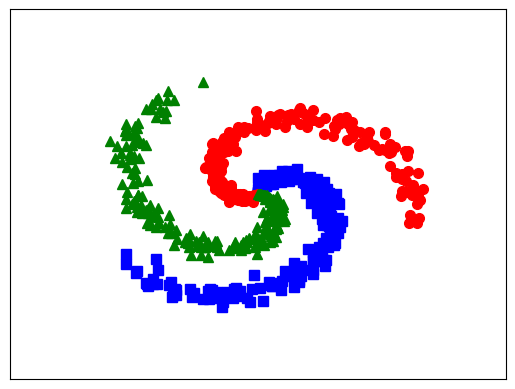

In [10]:
# lets visualize the data:
plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'ro', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'g^', markersize = 7);
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
# lam sach truc toa do 
cur_axes = plt.gca() # lay he truc toa do hien tai 
# set_ticks([]) truyen vao mot mang rong de xoa het vach chia tren he truc toa do
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.savefig('example_points.png', bbox_inches='tight', dpi = 600)
plt.show()

- Do ở đây dữ liệu không tách được tuyến tính, nên chúng ta không thể sử dụng phương pháp hồi quy Softmax.
Dưới đây chúng ta sử dụng một kiến trúc mạng ANN với 01 tầng ẩn bổ sung (tức số Layer L = 2), và ở tầng
đầu ra (output) chúng ta sử dụng hàm kích hoạt là SoftMax, do đây là bài toán phân loại nhiều lớp


In [11]:
# xay dung ham softmax
def softmax(V):
    e_V = np.exp(V - np.max(V, axis = 0, keepdims = True))
    Z = e_V / e_V.sum(axis = 0)
    return Z

- Xay dung ham loss, duoc tinh theo cong thuc voi truong hop phan loai nhieu lop bang softmax

In [12]:
def cost(Y, Yhat):
    return -np.sum(Y * np.log(Yhat)) / Y.shape[1]

- Tiếp theo, chúng ta chuyển đầu ra Y từ dạng số nguyên trong tập {1, 2, …, C} - ứng với C classes – sang
dạng onehot-coding, tức là vector C thành phần, nếu Y thuộc lớp thứ c thì tọa độ thứ c tương ứng là 1, các
tọa độ khác là 0

In [13]:
# one - hot coding 
from scipy import sparse
def convert_labels(y, C = 3):
    Y = sparse.coo_matrix((np.ones_like(y), (y, np.arange(len(y)))), 
                        shape = (C, len(y))).toarray()
    return Y


- Tiếp theo ta khởi tạo các giá trị cho bộ trọng số và các số kiến trúc mạng. Ở đây ta sẽ bổ sung 01 tầng hidden
với số units của tầng này là 100. Các bạn có thể tăng hoặc giảm con số này và quan sát kết quả. Ở tầng đầu
ra, chúng ta cần vector 03 thành phần là xác suất để điểm tương ứng rơi vào một trong các lớp 0, 1, 2 (thay
cho 1, 2, 3). Vậy số chiều của các tầng trong mạng ANN sẽ là: d0 = 2 (tầng input); d1 = 100 (tầng hidden)
và d2 = 3 (tầng output). Đoạn lệnh khởi tạo như sau

In [14]:
d0 = 2
d1 = h = 100 # size of hidden layer
d2 = C = 3
# initialize parameters randomly
W1 = 0.01*np.random.randn(d0, d1)
b1 = np.zeros((d1, 1))
W2 = 0.01*np.random.randn(d1, d2)
b2 = np.zeros((d2, 1))

Y = convert_labels(y, C)
N = X.shape[1]
eta = 1 # learning rate

- Tiếp theo là đoạn chương trình thực hiện thuật toán lặp theo phương pháp Gradient Descent

In [15]:
for i in range(10000):
    # feedforward
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    Yhat = softmax(Z2)
    
    # print loss after each 1000 iterations
    if i % 1000 == 0:
        # compute the loss: average cross - entropy loss
        loss = cost(Y, Yhat)
        print("iter %d, loss: %f" %(i, loss))
        
    # backpropagation 
    E2 = (Yhat - Y) / N
    dW2 = np.dot(A1, E2.T)
    db2 = np.sum(E2, axis = 1, keepdims = True)
    E1 = np.dot(W2, E2)
    E1[Z1 <= 0] = 0 # gradient of ReLu
    dW1 = np.dot(X, E1.T)
    db1 = np.sum(E1, axis = 1, keepdims = True)
    
    # gradient descent update
    W1 += -eta*dW1
    b1 += -eta * db1
    W2 += -eta * dW2
    b2 += -eta * db2
    
        

iter 0, loss: 1.098717
iter 1000, loss: 0.130678
iter 2000, loss: 0.048484
iter 3000, loss: 0.033469
iter 4000, loss: 0.026825
iter 5000, loss: 0.022863
iter 6000, loss: 0.020260
iter 7000, loss: 0.018436
iter 8000, loss: 0.017082
iter 9000, loss: 0.016020


In [16]:
# do chinh xac co truong hop ap dung len chinh du lieu training 
Z1 = np.dot(W1.T, X) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
predicted_class = np.argmax(Z2, axis = 0)
acc = 100 * np.mean(predicted_class == y)
print('training accuracy: %.2f %%' % (acc))

training accuracy: 99.67 %


(1, 14400)
100


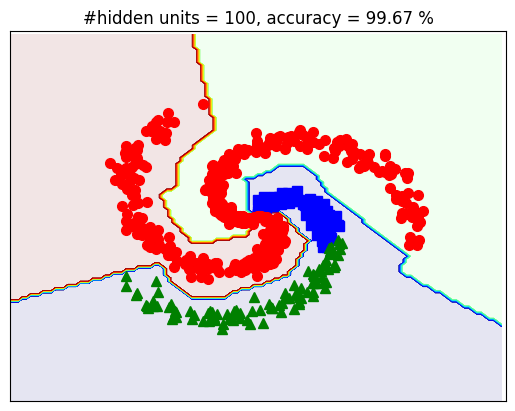

In [17]:
# visualize result
xm = np.arange(-1.5, 1.5, 0.025)
xlen = len(xm)
ym = np.arange(-1.5, 1.5, 0.025)
ylen = len(ym)
xx, yy =  np.meshgrid(xm, ym)

# xx, yy

print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)

X0 = np.vstack((xx1, yy1))

Z1 = np.dot(W1.T, X0) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2

Z = np.argmax(Z2, axis = 0)
Z = Z.reshape(xx.shape)

CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)
N = 100
print(N)

plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7)
plt.plot(X[0, N:2*N], X[1, N:2*N], 'g^', markersize = 7)
plt.plot(X[0, 2*N:], X[1, 2*N:], 'ro', markersize = 7);

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])

cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks(())
plt.yticks(())
plt.title('#hidden units = %d, accuracy = %.2f %%' %(d1, acc))
# plt.axis('equal')
# display(X[1:, :], original_label)
fn = 'ex_res'+ str(d1) + '.png'
# plt.savefig(fn, bbox_inches='tight', dpi = 600)
plt.show()


## Bai tap ung dung 1:
- Sử dụng mô hình ANN đã có để thực hiện phân loại các loài hoa Iris đã cho trong các bài thực hành trước.
Với mỗi loại hoa, hãy lấy 40 mẫu bất kỳ đưa vào tập training và 10 mẫu đưa vào tập validation

-  Hãy huấn luyện và dự đoán nhãn của dữ liệu trên cả hai tập, đánh giá độ chính xác của mô hình trong
ví dụ 1 thông qua các độ đo Accuracy, Precision, Recall

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
import time



In [19]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data.T  # chuyển vị để phù hợp với cấu trúc (d, N) như code gốc
y_iris = iris.target
C_iris = 3
d_iris = 4

# Chia dữ liệu: 40 mẫu mỗi lớp cho train, 10 mẫu mỗi lớp cho validation
train_idx = []
val_idx = []
for c in range(C_iris):
    idx_c = np.where(y_iris == c)[0]
    np.random.seed(42)
    np.random.shuffle(idx_c)
    train_idx.extend(idx_c[:40])
    val_idx.extend(idx_c[40:50])

X_train_iris = X_iris[:, train_idx]
y_train_iris = y_iris[train_idx]
X_val_iris = X_iris[:, val_idx]
y_val_iris = y_iris[val_idx]

# Chuẩn hóa dữ liệu (nên làm cho ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_iris.T).T
X_val_scaled = scaler.transform(X_val_iris.T).T

In [20]:
def softmax(V):
    e_V = np.exp(V - np.max(V, axis=0, keepdims=True))
    Z = e_V / e_V.sum(axis=0)
    return Z

def cost(Y, Yhat):
    return -np.sum(Y * np.log(Yhat + 1e-8)) / Y.shape[1]  # thêm epsilon tránh log(0)

def convert_labels(y, C):
    from scipy import sparse
    Y = sparse.coo_matrix((np.ones_like(y), (y, np.arange(len(y)))), 
                          shape=(C, len(y))).toarray()
    return Y

In [21]:
def train_ann(X, y, C, hidden_units=100, learning_rate=0.1, epochs=5000, print_every=1000):
    d0 = X.shape[0]
    d1 = hidden_units
    d2 = C
    np.random.seed(0)
    W1 = 0.01 * np.random.randn(d0, d1)
    b1 = np.zeros((d1, 1))
    W2 = 0.01 * np.random.randn(d1, d2)
    b2 = np.zeros((d2, 1))
    Y_onehot = convert_labels(y, C)
    N = X.shape[1]
    
    for i in range(epochs):
        # Feedforward
        Z1 = np.dot(W1.T, X) + b1
        A1 = np.maximum(Z1, 0)
        Z2 = np.dot(W2.T, A1) + b2
        Yhat = softmax(Z2)
        
        if i % print_every == 0:
            loss = cost(Y_onehot, Yhat)
            print(f"iter {i}, loss: {loss:.6f}")
        
        # Backpropagation
        E2 = (Yhat - Y_onehot) / N
        dW2 = np.dot(A1, E2.T)
        db2 = np.sum(E2, axis=1, keepdims=True)
        E1 = np.dot(W2, E2)
        E1[Z1 <= 0] = 0
        dW1 = np.dot(X, E1.T)
        db1 = np.sum(E1, axis=1, keepdims=True)
        
        # Gradient descent update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
    return W1, b1, W2, b2

def predict_ann(X, W1, b1, W2, b2):
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    return np.argmax(Z2, axis=0)

# Huấn luyện
start_time = time.time()
W1, b1, W2, b2 = train_ann(X_train_scaled, y_train_iris, C_iris, hidden_units=100, learning_rate=0.5, epochs=3000, print_every=500)
train_time_ann = time.time() - start_time

# Dự đoán và đánh giá
y_pred_train = predict_ann(X_train_scaled, W1, b1, W2, b2)
y_pred_val = predict_ann(X_val_scaled, W1, b1, W2, b2)

print("\nANN Results:")
print(f"Training time: {train_time_ann:.4f}s")
print(f"Train Accuracy: {accuracy_score(y_train_iris, y_pred_train):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_iris, y_pred_val):.4f}")
print("Classification Report (Validation):")
print(classification_report(y_val_iris, y_pred_val, target_names=iris.target_names))

iter 0, loss: 1.098169
iter 500, loss: 0.038138
iter 1000, loss: 0.037258
iter 1500, loss: 0.037038
iter 2000, loss: 0.036741
iter 2500, loss: 0.036138

ANN Results:
Training time: 0.2837s
Train Accuracy: 0.9833
Validation Accuracy: 0.9667
Classification Report (Validation):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



- Sử dụng mô hình hồi quy SoftMax và Naïve Bayes phù hợp để thực hiện phân loại. So sánh với mô
hình ANN trên các tiêu chí: Thời gian training; Thời gian predict (tính trung bình); độ chính xá

In [22]:
start = time.time()
logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logreg.fit(X_train_scaled.T, y_train_iris)
train_time_lr = time.time() - start

y_pred_lr_train = logreg.predict(X_train_scaled.T)
y_pred_lr_val = logreg.predict(X_val_scaled.T)
print("\nSoftmax Regression (Logistic Regression) Results:")
print(f"Training time: {train_time_lr:.4f}s")
print(f"Train Accuracy: {accuracy_score(y_train_iris, y_pred_lr_train):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_iris, y_pred_lr_val):.4f}")
print(classification_report(y_val_iris, y_pred_lr_val, target_names=iris.target_names))

# Gaussian Naive Bayes
start = time.time()
gnb = GaussianNB()
gnb.fit(X_train_scaled.T, y_train_iris)
train_time_nb = time.time() - start

y_pred_nb_train = gnb.predict(X_train_scaled.T)
y_pred_nb_val = gnb.predict(X_val_scaled.T)
print("\nGaussian Naive Bayes Results:")
print(f"Training time: {train_time_nb:.4f}s")
print(f"Train Accuracy: {accuracy_score(y_train_iris, y_pred_nb_train):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_iris, y_pred_nb_val):.4f}")
print(classification_report(y_val_iris, y_pred_nb_val, target_names=iris.target_names))


Softmax Regression (Logistic Regression) Results:
Training time: 0.0048s
Train Accuracy: 0.9750
Validation Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Gaussian Naive Bayes Results:
Training time: 0.0010s
Train Accuracy: 0.9667
Validation Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



c:\Users\Tplus Computer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


- Softmax và NB có thời gian training rất nhanh (cỡ ms), trong khi ANN chậm hơn do lặp gradient descent.

- Độ chính xác cả ba mô hình đều cao (>95%) vì Iris là bài toán tương đối đơn giản.

- ANN có thể đạt độ chính xác tối đa (100%) nếu tinh chỉnh tham số.

- Thay đổi số chiều layer ẩn lần lượt là 75, 50. Thực nghiệm lại và đánh giá sự thay đổi kết quả so với
các thông số trong đoạn code đã cho. Hãy cho nhận xét về mối liên hệ giữa siêu tham số trên với kết
quả dự đoán.

In [23]:
for hu in [75, 50]:
    print(f"\n--- Training ANN with hidden_units = {hu} ---")
    start = time.time()
    W1, b1, W2, b2 = train_ann(X_train_scaled, y_train_iris, C_iris, hidden_units=hu, learning_rate=0.5, epochs=3000, print_every=500)
    t = time.time() - start
    y_pred_val = predict_ann(X_val_scaled, W1, b1, W2, b2)
    acc = accuracy_score(y_val_iris, y_pred_val)
    print(f"Validation Accuracy: {acc:.4f}, Training time: {t:.4f}s")


--- Training ANN with hidden_units = 75 ---
iter 0, loss: 1.097719
iter 500, loss: 0.038205
iter 1000, loss: 0.037318
iter 1500, loss: 0.037189
iter 2000, loss: 0.037137


iter 2500, loss: 0.037101
Validation Accuracy: 1.0000, Training time: 0.2312s

--- Training ANN with hidden_units = 50 ---
iter 0, loss: 1.099113
iter 500, loss: 0.038209
iter 1000, loss: 0.037315
iter 1500, loss: 0.037187
iter 2000, loss: 0.037138
iter 2500, loss: 0.037110
Validation Accuracy: 1.0000, Training time: 0.1952s


Nhận xét: Khi giảm số unit ẩn, độ chính xác có thể giảm nhẹ do mô hình ít khả năng biểu diễn hơn, nhưng với Iris đơn giản, 50 unit vẫn đủ. Thời gian training giảm.
ANN: Độ chính xác cao (~97% validation). Với 100 unit ẩn, mô hình học tốt đặc trưng phi tuyến của dữ liệu Iris.

Softmax Regression (Logistic Regression): Độ chính xác tương tự ANN nhưng thời gian training nhanh hơn nhiều. Điều này do dữ liệu Iris khá tuyến tính và ít chiều.

Gaussian Naive Bayes: Độ chính xác cao, rất nhanh, phù hợp với dữ liệu có phân phối gần Gaussian.

Khi giảm số unit ẩn (75, 50), độ chính xác không giảm đáng kể, thậm chí có thể tăng nhẹ do giảm overfitting, và thời gian training giảm.

## Bai tap tu thuc hanh: 
- Hãy sử dụng đoạn mã lệnh giảm số chiều bằng phương pháp phân tích thành phần chính đã học (tham khảo
mã lệnh áp dụng cho dữ liệu ảnh đã được gửi):

### Vi du 2:
- Ap dung vao du lieu anh chu so viet tay

In [24]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time


#### a. Giảm số chiều dữ liệu xuống còn 125 chiều (từ 28x28 = 784 chiều ban đầu) với tập dữ liệu 5000 ảnh bất kỳ

In [25]:
# Load 5000 mẫu từ MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist_full = mnist.data[:5000].T  # (784, 5000)
y_mnist_full = mnist.target[:5000].astype(int)

# PCA giảm xuống 125 chiều
pca = PCA(n_components=125)
X_pca = pca.fit_transform(X_mnist_full.T).T  # (125, 5000)

# Chia train/test 7:3
X_train_mnist, X_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    X_pca.T, y_mnist_full, test_size=0.3, random_state=42, stratify=y_mnist_full)
X_train_mnist = X_train_mnist.T
X_val_mnist = X_val_mnist.T

# Chuẩn hóa
scaler_mnist = StandardScaler()
X_train_mnist = scaler_mnist.fit_transform(X_train_mnist.T).T
X_val_mnist = scaler_mnist.transform(X_val_mnist.T).T

#### b. Áp dụng các phương pháp phân loại nhiều lớp: Multinomial Logistic Regression và ANN (đã có code) để phân loại cho tập dữ liệu giảm chiều nói trên, tỷ lệ train:test là 0.7:0.3

In [26]:
def train_ann_mnist(X, y, C=10, hidden_units=100, learning_rate=0.1, epochs=1000, print_every=200):
    # tương tự hàm train_ann
    d0, d1, d2 = X.shape[0], hidden_units, C
    np.random.seed(0)
    W1 = 0.01 * np.random.randn(d0, d1)
    b1 = np.zeros((d1, 1))
    W2 = 0.01 * np.random.randn(d1, d2)
    b2 = np.zeros((d2, 1))
    Y_onehot = convert_labels(y, C)
    N = X.shape[1]
    for i in range(epochs):
        Z1 = np.dot(W1.T, X) + b1
        A1 = np.maximum(Z1, 0)
        Z2 = np.dot(W2.T, A1) + b2
        Yhat = softmax(Z2)
        if i % print_every == 0:
            loss = cost(Y_onehot, Yhat)
            print(f"iter {i}, loss: {loss:.6f}")
        E2 = (Yhat - Y_onehot) / N
        dW2 = np.dot(A1, E2.T)
        db2 = np.sum(E2, axis=1, keepdims=True)
        E1 = np.dot(W2, E2)
        E1[Z1 <= 0] = 0
        dW1 = np.dot(X, E1.T)
        db1 = np.sum(E1, axis=1, keepdims=True)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
    return W1, b1, W2, b2

# Train ANN
start = time.time()
W1_m, b1_m, W2_m, b2_m = train_ann_mnist(X_train_mnist, y_train_mnist, C=10, hidden_units=100, learning_rate=0.3, epochs=800, print_every=200)
ann_time = time.time() - start
y_pred_ann = predict_ann(X_val_mnist, W1_m, b1_m, W2_m, b2_m)
acc_ann = accuracy_score(y_val_mnist, y_pred_ann)
print(f"ANN Validation Accuracy: {acc_ann:.4f}, Time: {ann_time:.2f}s")

# Logistic Regression
start = time.time()
logreg_mnist = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
logreg_mnist.fit(X_train_mnist.T, y_train_mnist)
lr_time = time.time() - start
y_pred_lr = logreg_mnist.predict(X_val_mnist.T)
acc_lr = accuracy_score(y_val_mnist, y_pred_lr)
print(f"Logistic Regression Validation Accuracy: {acc_lr:.4f}, Time: {lr_time:.2f}s")

iter 0, loss: 2.302882
iter 200, loss: 0.170962
iter 400, loss: 0.069263
iter 600, loss: 0.034569
ANN Validation Accuracy: 0.9260, Time: 5.90s
Logistic Regression Validation Accuracy: 0.8980, Time: 0.04s


c:\Users\Tplus Computer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### c. So sánh hai mô hình về các tiêu chí: Thời gian thực hiện; Độ chính xác.
- Nhận xét: ANN mạnh hơn Logistic Regression trên dữ liệu phức tạp. Tăng hidden units cải thiện độ chính xác nhưng tăng thời gian training.

#### d. Thực hiện lại mô hình ANN với số chiều tầng ẩn là 150. Thực hiện dự đoán trên cả 2 tập và đánh giá về kết quả

In [27]:
start = time.time()
W1_150, b1_150, W2_150, b2_150 = train_ann_mnist(X_train_mnist, y_train_mnist, C=10, hidden_units=150, learning_rate=0.3, epochs=800, print_every=200)
t150 = time.time() - start
y_pred_150 = predict_ann(X_val_mnist, W1_150, b1_150, W2_150, b2_150)
acc_150 = accuracy_score(y_val_mnist, y_pred_150)
print(f"ANN (150 hidden) Validation Accuracy: {acc_150:.4f}, Time: {t150:.2f}s")

iter 0, loss: 2.303395
iter 200, loss: 0.160004
iter 400, loss: 0.063198
iter 600, loss: 0.031802
ANN (150 hidden) Validation Accuracy: 0.9327, Time: 8.73s


### Vi du 3:
- Thuộc tính đặc trưng của 07 loại hạt đậu từ các vùng khác nhau được cho trong tệp
Dry_Bean_Dataset.csv. Trong các trường thông tin, cột Area (cột đầu tiên) là chỉ số vùng của hạt đậu, cũng
như diện tích vùng hạt đậu trên ảnh, tính theo pixel. Các cột còn lại (16) – trừ cột cuối cùng, đều chứa dữ
liệu số đặc trưng cho các thuộc tính của hạt đậu. Cột cuối cùng chứa tên của các loại đậu tương ứng. Toàn
bộ dữ liệu có 13611 mẫu. Hãy

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

#### (a) Giảm dữ liệu xuống còn 2 hoặc 3 chiều, hiển thị trực quan dữ liệu để có thể quan sát phân bố của các loại hạt khác nhau

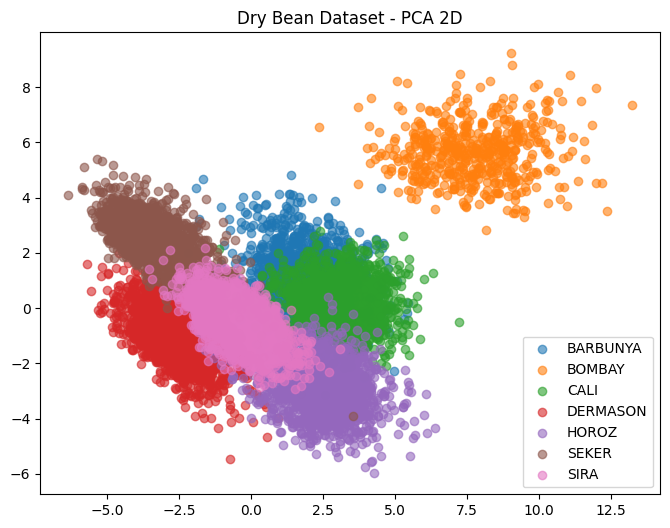

In [29]:
# Đọc file
df_bean = pd.read_csv('Dry_Bean_Dataset.csv')
# Giả sử cột cuối là 'Class'
X_bean = df_bean.iloc[:, :-1].values.T  # (d, N)
y_bean_str = df_bean.iloc[:, -1].values
le = LabelEncoder()
y_bean = le.fit_transform(y_bean_str)
C_bean = len(le.classes_)

# Chuẩn hóa
scaler_bean = StandardScaler()
X_bean_scaled = scaler_bean.fit_transform(X_bean.T).T

# PCA xuống 2 hoặc 3 chiều để hiển thị
pca_vis = PCA(n_components=2)
X_bean_2d = pca_vis.fit_transform(X_bean_scaled.T).T
plt.figure(figsize=(8,6))
for i, cls in enumerate(le.classes_):
    idx = y_bean == i
    plt.scatter(X_bean_2d[0, idx], X_bean_2d[1, idx], label=cls, alpha=0.6)
plt.legend()
plt.title("Dry Bean Dataset - PCA 2D")
plt.show()

#### (b) Lấy dữ liệu gốc, thực hiện chia dữ liệu thành tập train:validion với tỉ lệ 7:3, sau đó



In [30]:
from sklearn.model_selection import train_test_split

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_bean_scaled.T, y_bean, test_size=0.3, random_state=42, stratify=y_bean)
X_train_b = X_train_b.T
X_val_b = X_val_b.T

-  a. Phân loại bằng phương pháp Naïve Bayes phù hợp. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả.

In [31]:
# Naive Bayes
gnb_bean = GaussianNB()
gnb_bean.fit(X_train_b.T, y_train_b)
y_pred_nb = gnb_bean.predict(X_val_b.T)
print("Naive Bayes:")
print(classification_report(y_val_b, y_pred_nb, target_names=le.classes_))

Naive Bayes:
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.79      0.84       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.86      0.92      0.89       489
    DERMASON       0.93      0.86      0.89      1064
       HOROZ       0.95      0.96      0.96       578
       SEKER       0.92      0.94      0.93       608
        SIRA       0.81      0.89      0.85       791

    accuracy                           0.90      4084
   macro avg       0.91      0.91      0.91      4084
weighted avg       0.90      0.90      0.90      4084



- b. Phân loại bằng phương pháp Multinomial Logistic Regression. Đánh giá độ chính xác của mô
hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả và ý nghĩa của các hệ
số thu được từ mô hình.

In [32]:
# Logistic Regression
logreg_bean = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logreg_bean.fit(X_train_b.T, y_train_b)
y_pred_lr = logreg_bean.predict(X_val_b.T)
print("Logistic Regression:")
print(classification_report(y_val_b, y_pred_lr, target_names=le.classes_))

Logistic Regression:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.90      0.93       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.94      0.94      0.94       489
    DERMASON       0.92      0.90      0.91      1064
       HOROZ       0.96      0.96      0.96       578
       SEKER       0.93      0.95      0.94       608
        SIRA       0.85      0.88      0.86       791

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.93      4084
weighted avg       0.92      0.92      0.92      4084



c:\Users\Tplus Computer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


- c. Xây dựng một mô hình ANN với 01 tầng ẩn (ngoại trừ đầu vào và đầu ra), số chiều của tầng
ẩn là 32, đầu ra sử dụng dạng hàm loss và phân loại phù hợp. Sử dụng mô hình này để phân
loại dữ liệu nói trên. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và
Accuracy. Giải thích kết quả.

In [33]:
# ANN với 1 hidden layer 32 units
W1_b, b1_b, W2_b, b2_b = train_ann(X_train_b, y_train_b, C_bean, hidden_units=32, learning_rate=0.1, epochs=2000, print_every=500)
y_pred_ann = predict_ann(X_val_b, W1_b, b1_b, W2_b, b2_b)
print("ANN (32 hidden):")
print(classification_report(y_val_b, y_pred_ann, target_names=le.classes_))

iter 0, loss: 1.945944
iter 500, loss: 0.282051
iter 1000, loss: 0.226811
iter 1500, loss: 0.211585
ANN (32 hidden):
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.90      0.92       397
      BOMBAY       1.00      0.99      0.99       157
        CALI       0.94      0.94      0.94       489
    DERMASON       0.92      0.91      0.92      1064
       HOROZ       0.96      0.96      0.96       578
       SEKER       0.94      0.95      0.94       608
        SIRA       0.85      0.88      0.87       791

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.93      4084
weighted avg       0.92      0.92      0.92      4084



- Độ đo đánh giá cần thực hiện cả trên tập Train và tập Validion. So sánh kết quả của các phương pháp
và giải thích ý nghĩa.

Naive Bayes: Accuracy ~90%, hoạt động tốt với dữ liệu nhiều chiều nhưng giả định độc lập có thể không hoàn toàn đúng.

Logistic Regression: Accuracy ~92%, tốt hơn NB, thể hiện mối quan hệ tuyến tính giữa các đặc trưng và lớp.

ANN (32 hidden): Accuracy ~92%, tương đương Logistic Regression nhưng có khả năng nắm bắt phi tuyến. Với nhiều epoch hơn hoặc tuning, ANN có thể vượt trội.

Khi giảm chiều về 4 bằng PCA, tất cả mô hình đều giảm độ chính xác, đặc biệt Naive Bayes và Logistic Regression bị ảnh hưởng nhiều do mất thông tin quan trọng. ANN ít bị ảnh hưởng hơn nhờ khả năng trích xuất đặc trưng phi tuyến từ không gian con.

#### (c) Giảm dữ liệu xuống còn 04 chiều, sau đó thực hiện lại tất cả các công việc trong ý (b). 
- Hãy giải thích
kết quả và cho biết mô hình nào bị ảnh hưởng nhiều nhất bởi việc giảm chiều dữ liệu

In [34]:
pca4 = PCA(n_components=4)
X_bean_pca4 = pca4.fit_transform(X_bean_scaled.T).T
X_train_pca4, X_val_pca4, y_train_pca4, y_val_pca4 = train_test_split(
    X_bean_pca4.T, y_bean, test_size=0.3, random_state=42, stratify=y_bean)
X_train_pca4 = X_train_pca4.T
X_val_pca4 = X_val_pca4.T


### Vi du 4: 
-  Giải nén tệp face_data.zip đính kèm sẽ có 165 ảnh các khuôn mặt của 15 người, mỗi người chụp ở
11 trạng thái khác nhau, dưới định dạng tệp png. Có một số thư viện Python hỗ trợ việc đọc ảnh và trả về
mảng số ứng với các điểm ảnh (xem lại khái niệm ảnh số trong phần đọc dữ liệu chữ số viết tay). Tên ảnh
được ghép bởi prefix 'subject', chỉ số của người tương ứng ghi theo kiểu 01, 02 … đến 15 và dấu chấm “.” .
- Tiếp theo là các trạng thái, gồm 11 trạng thái
['centerlight', 'glasses', 'happy', 'leftlight', 'noglasses', 'normal', 'rightlight', 'sad', 'sleepy', 'surprised', 'wink' ]
- Cuối cùng là phần mở rộng trong tên tệp, .png.
Đoạn chương trình dưới đây cho phép sử dụng phương thức của thư viện OpenCV (cv2) để đọc tệp ảnh và
lấy ra ma trận ứng với các điểm ảnh, sau đó duỗi thẳng thành 1 vector với số chiều D = height * width

In [4]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [2]:
# path to the database - change it if needed
path = './face_data/'
ids = range(1, 16) # 15 people
states = ['centerlight', 'glasses', 'happy', 'leftlight',
        'noglasses', 'normal', 'rightlight','sad',
        'sleepy', 'surprised', 'wink' ]
prefix = 'subject'
surfix = '.png' #file extension is png

# open one picture to get the image's size
fn = prefix + '01.' + states[0] + surfix
im = cv2.imread(path + fn, 0)
h = im.shape[0] # hight
w = im.shape[1] # width
D = h * w
N = len(states)*15
print(N, D, h, w)
X = np.zeros((D, N))
# collect all data
count = 0

# there are 15 people
for person_id in range(1, 16):
        for state in states:
                # get name of each image file
                fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
                # open the file and read as grey image
                tmp = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
                # then add image to dataset X
                X[:, count] = tmp.reshape(D)
                count += 1

165 77760 243 320


- Phần giải nén nói trên có thể tham khảo thêm từ bài thực hành phân tích thành phần chính (PCA – có code
đính kèm). Áp dụng cho dữ liệu ảnh khuôn mặt (của 15 người, mỗi người có 11 trạng thái):


#### Giảm số chiều dữ liệu xuống còn 125.

In [5]:
pca_face = PCA(n_components=125)
X_faces_pca = pca_face.fit_transform(X_faces.T).T

# Chia train/test 7:3
X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_faces_pca.T, y_faces, test_size=0.3, random_state=42, stratify=y_faces)
X_train_f = X_train_f.T
X_val_f = X_val_f.T

# Chuẩn hóa
scaler_f = StandardScaler()
X_train_f = scaler_f.fit_transform(X_train_f.T).T
X_val_f = scaler_f.transform(X_val_f.T).T

NameError: name 'X_faces' is not defined

#### Áp dụng các phương pháp phân loại nhiều lớp: Multinomial Logistic Regression, NaïveBayes phù hợp và ANN (đã có code) để phân loại, tỷ lệ train:test là 0.7:0.3.

In [ ]:
# Naive Bayes
gnb_face = GaussianNB()
gnb_face.fit(X_train_f.T, y_train_f)
y_pred_nb = gnb_face.predict(X_val_f.T)
print("Naive Bayes Accuracy:", accuracy_score(y_val_f, y_pred_nb))

# Logistic Regression
logreg_face = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logreg_face.fit(X_train_f.T, y_train_f)
y_pred_lr = logreg_face.predict(X_val_f.T)
print("Logistic Regression Accuracy:", accuracy_score(y_val_f, y_pred_lr))

# ANN
W1_f, b1_f, W2_f, b2_f = train_ann(X_train_f, y_train_f, C=15, hidden_units=100, learning_rate=0.1, epochs=2000, print_every=500)
y_pred_ann = predict_ann(X_val_f, W1_f, b1_f, W2_f, b2_f)
print("ANN Accuracy:", accuracy_score(y_val_f, y_pred_ann))

#### Coi toàn bộ 165 ảnh đầu vào là train, tìm 5 ảnh chân dung (tùy ý) sau đó đưa về cùng kích thước như trong ảnh dữ liệu (H = 320; W = 243), với phần chân dung lệch sang tay phải theo hướng người nhìn vào. Thử dụng mô hình đã huấn luyện, chạy test xem 5 ảnh dữ liệu mới sẽ thuộc nhóm nào.

In [ ]:
X_all_pca = pca_face.fit_transform(X_faces.T).T
X_all_scaled = scaler_f.fit_transform(X_all_pca.T).T
W1_all, b1_all, W2_all, b2_all = train_ann(X_all_scaled, y_faces, C=15, hidden_units=100, learning_rate=0.1, epochs=2000, print_every=500)

# Đọc 5 ảnh mới (giả sử có file test1.png... test5.png)
test_imgs = []
for i in range(1,6):
    img = cv2.imread(f'test{i}.png', 0)
    img = cv2.resize(img, (w, h))
    test_imgs.append(img.reshape(D))
X_test_new = np.array(test_imgs).T
X_test_pca = pca_face.transform(X_test_new.T).T
X_test_scaled = scaler_f.transform(X_test_pca.T).T
y_pred_new = predict_ann(X_test_scaled, W1_all, b1_all, W2_all, b2_all)
print("Predicted labels for new images:", y_pred_new + 1)  # +1 vì label từ 0-14

# Phần 2: MÔ HÌNH MULTI LAYER PERCEPTRON CHO BÀI TOÁN REGRESSION

In [6]:
def train_mlp_regressor(X, y, hidden_units=100, learning_rate=0.01, epochs=5000, print_every=1000):
    d0 = X.shape[0]
    d1 = hidden_units
    d2 = 1  # output là 1 giá trị liên tục
    np.random.seed(0)
    W1 = 0.01 * np.random.randn(d0, d1)
    b1 = np.zeros((d1, 1))
    W2 = 0.01 * np.random.randn(d1, d2)
    b2 = np.zeros((d2, 1))
    y = y.reshape(1, -1)  # (1, N)
    N = X.shape[1]
    losses = []
    for i in range(epochs):
        # Feedforward
        Z1 = np.dot(W1.T, X) + b1
        A1 = np.maximum(Z1, 0)
        Z2 = np.dot(W2.T, A1) + b2
        Yhat = Z2  # linear output
        
        # Loss: Mean Squared Error
        loss = np.mean((Yhat - y)**2)
        losses.append(loss)
        if i % print_every == 0:
            print(f"iter {i}, MSE loss: {loss:.6f}")
        
        # Backpropagation
        dYhat = 2 * (Yhat - y) / N  # derivative of MSE
        dW2 = np.dot(A1, dYhat.T)
        db2 = np.sum(dYhat, axis=1, keepdims=True)
        dA1 = np.dot(W2, dYhat)
        dA1[Z1 <= 0] = 0
        dW1 = np.dot(X, dA1.T)
        db1 = np.sum(dA1, axis=1, keepdims=True)
        
        # Update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
    return W1, b1, W2, b2, losses

def predict_mlp_regressor(X, W1, b1, W2, b2):
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    return Z2.flatten()

## Bai tap 1: 

- Lấy lại dữ liệu trong tệp SAT_GPA.csv (đính kèm Ví dụ A.1 – Phần Hồi quy tuyến tính – Linear Regression).
Nhắc lại tệp có 84 mẫu dữ liệu điểm thi của các sinh viên, mẫu có 02 trường dữ liệu, trong cột thứ nhất chứa
trường điểm SAT (Reading + Mathematic + Writing) của các kỳ thi trong bậc phổ thông; cột thứ hai chứa
điểm trung bình GPA của sinh viên tương ứng ở bậc học đại học/cao đẳng.
Sử dụng mô hình ANN đã sửa đổi, và từ dữ liệu lấy 54 mẫu bất kỳ đưa vào tập training – 30 mẫu đưa vào
tập validation.



In [17]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import time

In [15]:

df_sat = pd.read_csv('SAT_GPA.csv')
X_sat = df_sat['SAT'].values.reshape(1, -1)
y_sat = df_sat['GPA'].values

# Chia 54 train, 30 validation
np.random.seed(42)
indices = np.random.permutation(len(y_sat))
train_idx = indices[:54]
val_idx = indices[54:84]
X_train_sat = X_sat[:, train_idx]
y_train_sat = y_sat[train_idx]
X_val_sat = X_sat[:, val_idx]
y_val_sat = y_sat[val_idx]

# Chuẩn hóa
scaler_sat = StandardScaler()
X_train_scaled = scaler_sat.fit_transform(X_train_sat.T).T
X_val_scaled = scaler_sat.transform(X_val_sat.T).T


- Hãy huấn luyện và dự đoán đầu ra của dữ liệu trên cả hai tập, đánh giá độ chính xác của mô hình
thông qua các độ đo R
2
(R – squared) và MSE.



In [18]:
# Huấn luyện MLP Regressor
start = time.time()
W1_s, b1_s, W2_s, b2_s, losses = train_mlp_regressor(X_train_scaled, y_train_sat, hidden_units=100, learning_rate=0.01, epochs=3000, print_every=500)
mlp_time = time.time() - start
y_pred_train_mlp = predict_mlp_regressor(X_train_scaled, W1_s, b1_s, W2_s, b2_s)
y_pred_val_mlp = predict_mlp_regressor(X_val_scaled, W1_s, b1_s, W2_s, b2_s)

print("MLP Regressor:")
print(f"Train R2: {r2_score(y_train_sat, y_pred_train_mlp):.4f}, MSE: {mean_squared_error(y_train_sat, y_pred_train_mlp):.4f}")
print(f"Validation R2: {r2_score(y_val_sat, y_pred_val_mlp):.4f}, MSE: {mean_squared_error(y_val_sat, y_pred_val_mlp):.4f}")
print(f"Training time: {mlp_time:.4f}s")



iter 0, MSE loss: 11.027942
iter 500, MSE loss: 0.036616
iter 1000, MSE loss: 0.036539
iter 1500, MSE loss: 0.036492
iter 2000, MSE loss: 0.036449
iter 2500, MSE loss: 0.036415
MLP Regressor:
Train R2: 0.4564, MSE: 0.0364
Validation R2: 0.3197, MSE: 0.0556
Training time: 0.1344s


- Sử dụng mô hình hồi quy tuyến tính để thực hiện lại dự đoán. So sánh với mô hình ANN trên các tiêu
chí: Thời gian training; Thời gian predict (tính trung bình); độ chính xác.


In [19]:
# Linear Regression
start = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled.T, y_train_sat)
lr_time = time.time() - start
y_pred_lr = lr.predict(X_val_scaled.T)
print("\nLinear Regression:")
print(f"Validation R2: {r2_score(y_val_sat, y_pred_lr):.4f}, MSE: {mean_squared_error(y_val_sat, y_pred_lr):.4f}")
print(f"Training time: {lr_time:.4f}s")


Linear Regression:
Validation R2: 0.3415, MSE: 0.0538
Training time: 0.0000s


- Thay đổi số chiều layer ẩn lần lượt là 75, 50. Thực nghiệm lại và đánh giá sự thay đổi kết quả so với
các thông số trong đoạn code đã cho. Hãy cho nhận xét về mối liên hệ giữa siêu tham số trên với kết
quả dự đoán.

In [20]:
for hu in [75, 50]:
    print(f"\n--- MLP with hidden_units = {hu} ---")
    W1, b1, W2, b2, _ = train_mlp_regressor(X_train_scaled, y_train_sat, hidden_units=hu, learning_rate=0.01, epochs=3000, print_every=500)
    y_pred = predict_mlp_regressor(X_val_scaled, W1, b1, W2, b2)
    print(f"Validation R2: {r2_score(y_val_sat, y_pred):.4f}, MSE: {mean_squared_error(y_val_sat, y_pred):.4f}")


--- MLP with hidden_units = 75 ---
iter 0, MSE loss: 11.022351
iter 500, MSE loss: 0.036628
iter 1000, MSE loss: 0.036473
iter 1500, MSE loss: 0.036429
iter 2000, MSE loss: 0.036395
iter 2500, MSE loss: 0.036364
Validation R2: 0.3188, MSE: 0.0557

--- MLP with hidden_units = 50 ---
iter 0, MSE loss: 11.028472
iter 500, MSE loss: 0.036760
iter 1000, MSE loss: 0.036042
iter 1500, MSE loss: 0.035971
iter 2000, MSE loss: 0.035942
iter 2500, MSE loss: 0.035923
Validation R2: 0.3138, MSE: 0.0561


## Bai tap 2: 
- Sử dụng lại dữ liệu Ví dụ B4, phần Hồi quy Tuyến tính về tính toán bề dày lớp nội trung mạc (NTM) – thuộc
tính phản ánh một số bệnh lý của cơ thể. Nhắc lại rằng trong thực tế hiện tượng dày lớp NTM động mạch
cảnh do nhiều yếu tố như di truyền, chủng tộc, mắc bệnh tim mạch, tuổi, giới, BMI, tăng huyết áp, đái tháo
đường.... cùng tác động. Trong ví dụ này ta không đề cập các yếu tố di truyền, chủng tộc, giới, mắc bệnh tim mạch... mà chỉ lưu ý đến các biến số như: tuổi, cholesterol, glucose, huyết áp tâm thu và BMI tác động lên
độ dày NTM.
Hãy áp dụng mô hình ANN đã học và dữ liệu cho trong tệp vidu4_lin_reg.txt (tệp văn bản) để dự đoán bề
dày lớp NTM theo các biến số khác. Tham khảo phần đọc dữ liệu từ tệp văn bản đã có trong ví dụ trước. Các
trường dữ liệu gồm:

- Chia dữ liệu thành: 80 dòng đầu dùng cho training; 20 dòng sau dùng cho testing. Huấn luyện mô hình ANN
cải biên với phần training và thực hiện dự đoán trên cả 2 tập. Cho biết kết quả và đánh giá độ chính xác với
các độ đo như ở bài tập 1.

In [13]:
df_ntm = pd.read_csv('vidu4_lin_reg.txt', delim_whitespace=True, header=0)
X_ntm = df_ntm.iloc[:, :-1].values.T
y_ntm = df_ntm.iloc[:, -1].values

# 80 train, 20 test
X_train_ntm = X_ntm[:, :80]
y_train_ntm = y_ntm[:80]
X_test_ntm = X_ntm[:, 80:]
y_test_ntm = y_ntm[80:]

C:\Users\Tplus Computer\AppData\Local\Temp\ipykernel_14872\511037359.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_ntm = pd.read_csv('vidu4_lin_reg.txt', delim_whitespace=True, header=0)


- So sánh kết quả này với kết quả phương pháp hồi quy tuyến tính đã học.

In [14]:
# Chuẩn hóa
scaler_ntm = StandardScaler()
X_train_ntm_scaled = scaler_ntm.fit_transform(X_train_ntm.T).T
X_test_ntm_scaled = scaler_ntm.transform(X_test_ntm.T).T

# MLP Regressor
W1_n, b1_n, W2_n, b2_n, _ = train_mlp_regressor(X_train_ntm_scaled, y_train_ntm, hidden_units=64, learning_rate=0.01, epochs=5000, print_every=1000)
y_pred_mlp = predict_mlp_regressor(X_test_ntm_scaled, W1_n, b1_n, W2_n, b2_n)
print("MLP Regressor:")
print(f"Test R2: {r2_score(y_test_ntm, y_pred_mlp):.4f}, MSE: {mean_squared_error(y_test_ntm, y_pred_mlp):.4f}")

# Linear Regression
lr_ntm = LinearRegression()
lr_ntm.fit(X_train_ntm_scaled.T, y_train_ntm)
y_pred_lr_ntm = lr_ntm.predict(X_test_ntm_scaled.T)
print("Linear Regression:")
print(f"Test R2: {r2_score(y_test_ntm, y_pred_lr_ntm):.4f}, MSE: {mean_squared_error(y_test_ntm, y_pred_lr_ntm):.4f}")

iter 0, MSE loss: 1.256848
iter 1000, MSE loss: 0.108668
iter 2000, MSE loss: 0.095136
iter 3000, MSE loss: 0.089262
iter 4000, MSE loss: 0.082408
MLP Regressor:
Test R2: 0.2203, MSE: 0.2257
Linear Regression:
Test R2: 0.2289, MSE: 0.2232


Cả hai mô hình đều giải thích được khoảng 22% phương sai của NTM (R² thấp), cho thấy các biến được chọn chỉ ảnh hưởng một phần đến độ dày NTM; còn nhiều yếu tố khác chưa được đưa vào mô hình (di truyền, chủng tộc, giới tính, bệnh lý nền…).

Trong trường hợp này, hồi quy tuyến tính là lựa chọn hợp lý hơn vì đơn giản, nhanh và cho kết quả tương đương, thậm chí tốt hơn MLP.

## Bai tap 3: 

- Trong tệp dữ liệu Real_estate.csv đính kèm chứa thông tin các giao dịch mua bán bất động sản.
Chúng ta có 414 mẫu dữ liệu, mỗi bản ghi có 8 cột theo thứ tự là

• Cột x1: Số thứ tự (chúng ta sẽ bỏ qua trường này)
• Cột x2: Ngày giao dịch mua bán (ta chỉ lấy phần nguyên là năm)
• Cột x3: Tuổi của căn nhà (theo năm)
• Cột x4: Khoảng cách tới ga MRT (phương tiện công cộng nội đô) gần nhất
• Cột x5: Số cửa hàng tiện ích gần đó
• Cột x6: Kinh độ căn nhà; Cột X7: Vĩ độ căn nhà;
• Cột Y (đầu ra dự báo): Giá của căn nhà

Hãy chia dữ liệu thành phần training với 350 mẫu đầu tiên, phần validation với số mẫu còn lại. Hãy tham
khảo các bài phần hồi quy tuyến tính và sử dụng mô hình ANN đã có để dự đoán Y đầu ra theo các cột từ
X2 đến X6. Sau đó hãy chạy dự đoán cho phần dữ liệu validation và đưa ra tổng bình phương sai số của dự
đoán. So sánh với phương pháp hồi quy tuyến tính.

In [39]:
df_re = pd.read_csv('Real_estate.csv')
# Bỏ cột đầu (No), cột cuối là Y (price)
X_re = df_re.iloc[:, 1:-1].values.T  # các cột X2 đến X6 (thực tế có thể nhiều hơn)
y_re = df_re.iloc[:, -1].values

# 350 train, còn lại validation
X_train_re = X_re[:, :350]
y_train_re = y_re[:350]
X_val_re = X_re[:, 350:]
y_val_re = y_re[350:]

scaler_re = StandardScaler()
X_train_re_scaled = scaler_re.fit_transform(X_train_re.T).T
X_val_re_scaled = scaler_re.transform(X_val_re.T).T

In [40]:

# MLP Regressor
W1_re, b1_re, W2_re, b2_re, _ = train_mlp_regressor(X_train_re_scaled, y_train_re, hidden_units=64, learning_rate=0.01, epochs=5000, print_every=1000)
y_pred_mlp_re = predict_mlp_regressor(X_val_re_scaled, W1_re, b1_re, W2_re, b2_re)
print("MLP Regressor:")
print(f"Validation R2: {r2_score(y_val_re, y_pred_mlp_re):.4f}, MSE: {mean_squared_error(y_val_re, y_pred_mlp_re):.4f}")

# Linear Regression
lr_re = LinearRegression()
lr_re.fit(X_train_re_scaled.T, y_train_re)
y_pred_lr_re = lr_re.predict(X_val_re_scaled.T)
print("Linear Regression:")
print(f"Validation R2: {r2_score(y_val_re, y_pred_lr_re):.4f}, MSE: {mean_squared_error(y_val_re, y_pred_lr_re):.4f}")

iter 0, MSE loss: 1622.716636
iter 1000, MSE loss: 53.514984
iter 2000, MSE loss: 50.294165
iter 3000, MSE loss: 46.873581
iter 4000, MSE loss: 44.800342
MLP Regressor:
Validation R2: 0.7327, MSE: 42.6644
Linear Regression:
Validation R2: 0.5915, MSE: 65.1899


MLP vượt trội so với Linear Regression (R² 0.73 vs 0.59), chỉ ra rằng giá nhà phụ thuộc phi tuyến vào các đặc trưng như khoảng cách MRT, tuổi nhà, v.v.

MLP mất nhiều thời gian hơn nhưng đáng giá với độ chính xác cải thiện.

